# Example of evaluating electron repulsion integrals using the integral diagonal approximation (ERIDA) for Gausslet orbitals

In [1]:
import numpy as np
from scipy.stats import ortho_group
import matplotlib.pyplot as plt
# see the README for build and install instructions of this package
import gausslectronitegrate as gli

In [2]:
# Gausslet G10 coefficients
import sys
sys.path.append("../gausslets/")
from gausslets import get_gausslet_g10_coeffs
b_list, _ = get_gausslet_g10_coeffs()

In [3]:
# truncation tolerance
# (values close to zero imply higher accuracy but longer computation time)
tol = 1e-16

In [4]:
# compute the overlap integral for the two Gausslets centered at the origin
gli.compute_erida_gausslet_integral(b_list, ([0, 0, 0], [0, 0, 0]), tol)

2.4104836730129793

In [5]:
# evaluate the overlap integral for two other points, as an example
point_a = [-1,  0,  2]
point_b = [ 0,  1, -1]
gli.compute_erida_gausslet_integral(b_list, (point_a, point_b), tol)

0.3024908490984703

In [6]:
# define a symmetric Cartesian grid by tuples
# of the form (istart, num points)
# in each coordinate direction
grid = [
    (-3, 7),  # x
    (-3, 7),  # y
    (-3, 7),  # z
]

In [7]:
# overall number of grid points
gli.grid_num_points(grid)

343

In [8]:
# evaluate electron repulsion integrals
# using the integral diagonal approximation (ERIDA)
# for Gausslet orbitals centered at the grid points,
# taking translational, octahedral and permutational symmetries into account
erida = gli.compute_sparse_erida_gausslet_integrals(b_list, grid, tol)
type(erida)

gausslectronitegrate.SparseERIDA

In [9]:
# number of stored ERIDA values after taking symmetries into account
erida.num_entries

126

In [10]:
# query the integral value for the two Gausslets centered at the origin
# (should agree with above value)
erida.integral_value(([0, 0, 0], [0, 0, 0]))

2.4104836730129793

In [11]:
# query the integral value for the two other points
# (should agree with above value)
erida.integral_value((point_a, point_b))

0.3024908490984724

In [12]:
# obtain the dense matrix representation of the overlap integrals
# for all grid points
erida_matrix = erida.fill_matrix(grid)
erida_matrix.shape

(343, 343)

In [13]:
# show some entries
erida_matrix[:3, :3]

array([[2.41048367, 1.05555191, 0.46842533],
       [1.05555191, 2.41048367, 1.05555191],
       [0.46842533, 1.05555191, 2.41048367]])

In [14]:
# check i <-> j symmetry
print(np.linalg.norm(erida_matrix.T - erida_matrix))

0.0


In [15]:
# show the overlap integral value for both Gausslets centered at the origin
# linear index of origin (should agree with above value)
iorigin = gli.grid_point_to_linear_index(grid, [0, 0, 0])
erida_matrix[iorigin, iorigin]

2.4104836730129793

In [16]:
# read the integral value for the two other points
# (should agree with above value)
ia = gli.grid_point_to_linear_index(grid, point_a)
ib = gli.grid_point_to_linear_index(grid, point_b)
erida_matrix[ia, ib]

0.3024908490984724

In [17]:
# project ERIDA matrix onto a basis
rng = np.random.default_rng(731)
# draw 2 random orthogonal state vectors
basis = ortho_group.rvs(gli.grid_num_points(erida.grid), random_state=rng)[:, :2]
eri_tensor_proj = erida.project(basis)
print(type(eri_tensor_proj))
print(eri_tensor_proj.shape)

<class 'numpy.ndarray'>
(2, 2, 2, 2)


In [18]:
# show entries
eri_tensor_proj

array([[[[ 0.27512424, -0.00113926],
         [-0.00113926,  0.26871768]],

        [[-0.00113926,  0.0063663 ],
         [ 0.0063663 ,  0.00083313]]],


       [[[-0.00113926,  0.0063663 ],
         [ 0.0063663 ,  0.00083313]],

        [[ 0.26871768,  0.00083313],
         [ 0.00083313,  0.28285189]]]])

In [19]:
# reference calculation, using the Khatri-Rao product of the basis vectors
eri_tensor_proj_ref = np.einsum(
    basis, (4, 0),
    basis, (4, 1),
    basis, (5, 2),
    basis, (5, 3),
    erida_matrix, (4, 5),
    (0, 1, 2, 3), optimize=True)
# difference should be zero (up to rounding errors)
np.linalg.norm(eri_tensor_proj - eri_tensor_proj_ref)

3.8767249506350176e-15

In [20]:
# asymptotic decay behavior

pts_cartesian = [[i, 0, 0] for i in range(19)]
pts_diagonal  = [[i, i, i] for i in range(11)]

dists_cartesian = np.array([np.linalg.norm(pt) for pt in pts_cartesian])
dists_diagonal  = np.array([np.linalg.norm(pt) for pt in pts_diagonal])

erida_cartesian_list = [gli.compute_erida_gausslet_integral(b_list, ([0, 0, 0], pt), tol)
                        for pt in pts_cartesian]
erida_diagonal_list  = [gli.compute_erida_gausslet_integral(b_list, ([0, 0, 0], pt), tol)
                        for pt in pts_diagonal]

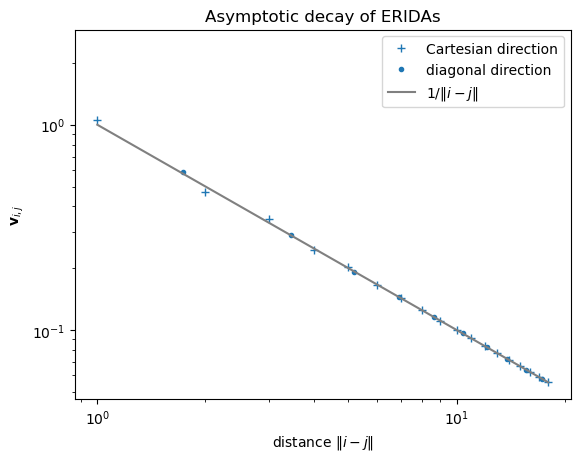

In [21]:
# visualize asymptotic decay behavior
plt.loglog(dists_cartesian, erida_cartesian_list, '+',
           color="tab:blue", label="Cartesian direction")
plt.loglog(dists_diagonal, erida_diagonal_list, '.',
           color="tab:blue", label="diagonal direction")
plt.loglog(dists_cartesian[1:], 1 / dists_cartesian[1:],
           color="gray", label=r"$1/\Vert i - j \Vert$")
plt.legend()
plt.xlabel(r"distance $\Vert i - j \Vert$")
plt.ylabel(r"$\mathbf{v}_{i,j}$")
plt.title("Asymptotic decay of ERIDAs")
plt.savefig("erida_integrals_asymptotic_decay_values.pdf")
plt.show()

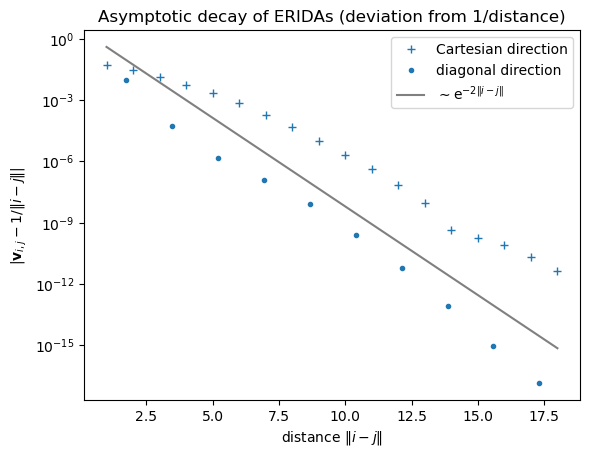

In [22]:
# visualize deviation from 1 / distance
plt.semilogy(dists_cartesian[1:], np.abs(erida_cartesian_list[1:] - 1 / dists_cartesian[1:]), '+',
             color="tab:blue", label="Cartesian direction")
plt.semilogy(dists_diagonal[1:], np.abs(erida_diagonal_list[1:] - 1 / dists_diagonal[1:]), '.',
             color="tab:blue", label="diagonal direction")
plt.semilogy(dists_cartesian[1:], 3*np.exp(-2*dists_cartesian[1:]),
             color="gray", label=r"$\sim \mathrm{e}^{-2 \Vert i - j \Vert}$")
plt.legend()
plt.xlabel(r"distance $\Vert i - j \Vert$")
plt.ylabel(r"$\left\vert\mathbf{v}_{i,j} - 1 / \Vert i - j \Vert\right\vert$")
plt.title("Asymptotic decay of ERIDAs (deviation from 1/distance)")
plt.savefig("erida_integrals_asymptotic_decay_deviation.pdf")
plt.show()